---

# 📏 Mediciones en Qiskit

### Introducción a la programación cuántica

**TECNOLÓGICO NACIONAL DE MÉXICO · CENIDET**  
**Oscar Alejandro López Campero · Agosto 2026**

---

## 🎯 ¿Qué veremos?

En este notebook aprenderemos a:

- agregar una medición a un circuito;
- ejecutar el circuito en un simulador;
- observar los resultados en un histograma;
- entender qué cambia cuando usamos más repeticiones.

> La idea es practicar primero. Más adelante estudiaremos estos conceptos con mayor profundidad.

---

# 🛠️ Preparación

Ejecuta las siguientes dos celdas antes de comenzar.

In [17]:
# Instalar Qiskit y las herramientas para dibujar gráficas.
%pip install -q "qiskit[visualization]"


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
# Herramientas para crear, simular y mostrar circuitos.
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

# Crearemos el simulador una sola vez y lo reutilizaremos.
simulador = BasicSimulator()

print("✅ Entorno preparado")

✅ Entorno preparado


---

# 1️⃣ ¿Qué es una medición?

La medición nos permite obtener un resultado clásico de un qubit.

- Si medimos `|0⟩`, obtenemos `0`.
- Si medimos `|1⟩`, obtenemos `1`.
- Si el qubit está en superposición, podemos obtener `0` o `1`.

Para medir utilizamos:

```python
circuito.measure(qubit, bit_clasico)
```

Por ejemplo, `circuito.measure(0, 0)` mide el qubit 0 y guarda el resultado en el bit clásico 0.

## Nuestro primer circuito con medición

Todos los qubits comienzan en `|0⟩`. Primero crearemos un circuito con:

| Elemento | Cantidad |
|---|:---:|
| Qubits | 1 |
| Bits clásicos | 1 |

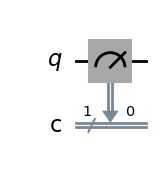

In [19]:
# El primer 1 representa un qubit.
# El segundo 1 representa un bit clásico.
circuito = QuantumCircuit(1, 1)

# Medir el qubit 0 y guardar el resultado en el bit clásico 0.
circuito.measure(0, 0)

# Mostrar el circuito.
display(circuito.draw('mpl'))

### ¿Cómo leemos el circuito?

1. El qubit comienza en `|0⟩`.
2. El símbolo de medición observa el qubit.
3. La flecha indica que el resultado se guarda en el bit clásico.

Por eso esperamos obtener solamente `0`.

---

# 2️⃣ Ejecutar y observar el resultado

La palabra **shots** indica cuántas veces repetiremos el circuito. Usaremos 100 repeticiones.

{'0': 100}


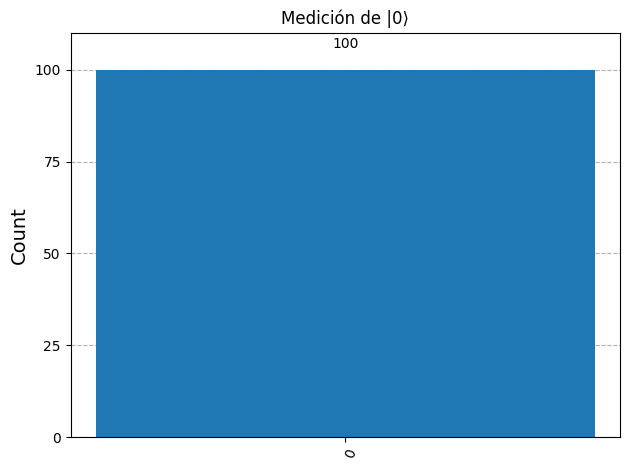

In [20]:
# Preparar el circuito para nuestro simulador.
circuito_preparado = transpile(circuito, simulador)

# Ejecutar el circuito 100 veces.
trabajo = simulador.run(circuito_preparado, shots=100)

# Obtener cuántas veces apareció cada resultado.
conteos = trabajo.result().get_counts()

print(conteos)
display(plot_histogram(conteos, title="Medición de |0⟩"))

El resultado debe parecerse a:

```text
{'0': 100}
```

Esto significa que obtuvimos `0` en las 100 repeticiones.

---

# 3️⃣ Medir el estado `|1⟩`

Para preparar `|1⟩`, aplicamos la compuerta X antes de medir.

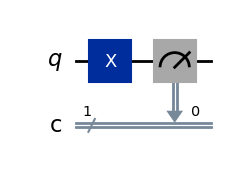

In [21]:
# Crear un circuito nuevo.
circuito_uno = QuantumCircuit(1, 1)

# X cambia el estado de |0⟩ a |1⟩.
circuito_uno.x(0)

# Medir y guardar el resultado.
circuito_uno.measure(0, 0)

display(circuito_uno.draw('mpl'))

{'1': 100}


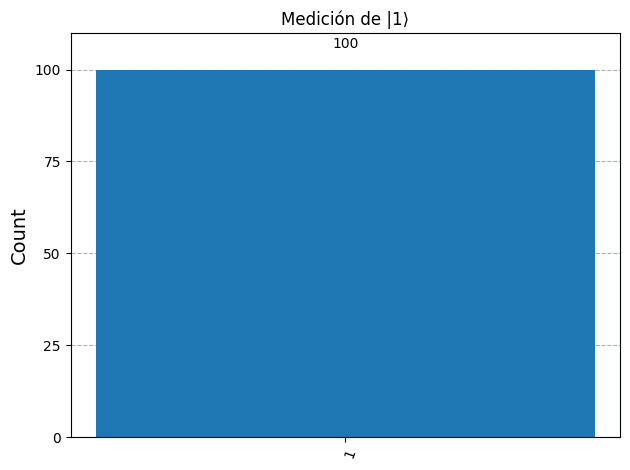

In [22]:
# Preparar y ejecutar el circuito 100 veces.
circuito_uno_preparado = transpile(circuito_uno, simulador)
trabajo_uno = simulador.run(circuito_uno_preparado, shots=100)
conteos_uno = trabajo_uno.result().get_counts()

print(conteos_uno)
display(plot_histogram(conteos_uno, title="Medición de |1⟩"))

Ahora el resultado debe ser:

```text
{'1': 100}
```

La compuerta X preparó el qubit en `|1⟩`, por eso siempre medimos `1`.

---

# 4️⃣ Medir después de una compuerta H

La compuerta H coloca al qubit en superposición. Al medirlo, algunas veces obtendremos `0` y otras veces `1`.

Esperamos resultados cercanos a **50 % y 50 %**, aunque no tienen que ser exactamente iguales.

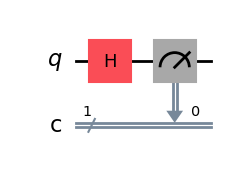

In [23]:
# Crear un circuito nuevo.
circuito_h = QuantumCircuit(1, 1)

# Colocar el qubit en superposición.
circuito_h.h(0)

# Medir el qubit.
circuito_h.measure(0, 0)

display(circuito_h.draw('mpl'))

{'0': 464, '1': 536}


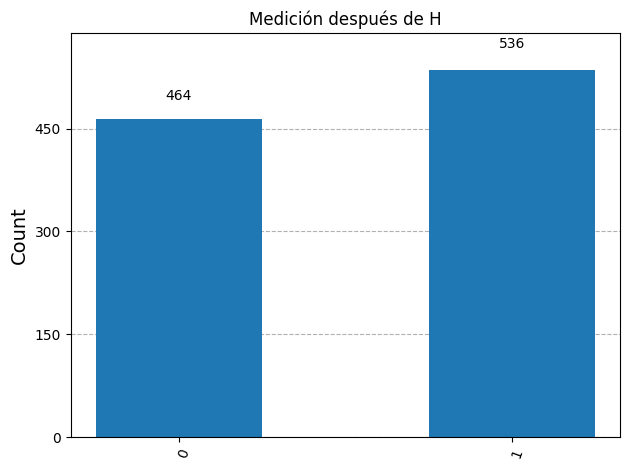

In [24]:
# Ejecutar el circuito 1,000 veces.
circuito_h_preparado = transpile(circuito_h, simulador)
trabajo_h = simulador.run(
    circuito_h_preparado,
    shots=1000,
    seed_simulator=2026
)
conteos_h = trabajo_h.result().get_counts()

print(conteos_h)
display(plot_histogram(conteos_h, title="Medición después de H"))

> 💡 Los números pueden cambiar un poco cada vez que ejecutamos el experimento. Eso es normal: la medición de una superposición es probabilística.

---

# 5️⃣ ¿Qué pasa si cambiamos los shots?

Probemos el mismo circuito primero con 10 shots y después con 1,000 shots.

10 shots: {'1': 6, '0': 4}
1000 shots: {'1': 498, '0': 502}


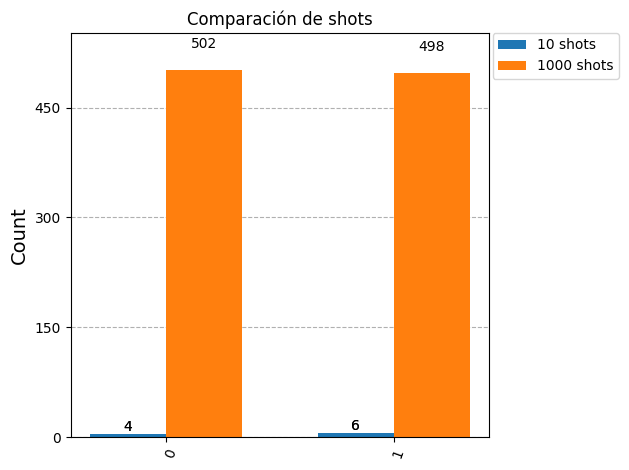

In [25]:
# Ejecutar el mismo circuito con pocas repeticiones.
resultado_10 = simulador.run(
    circuito_h_preparado,
    shots=10,
    seed_simulator=7
).result().get_counts()

# Ejecutarlo ahora con muchas repeticiones.
resultado_1000 = simulador.run(
    circuito_h_preparado,
    shots=1000,
    seed_simulator=7
).result().get_counts()

print("10 shots:", resultado_10)
print("1000 shots:", resultado_1000)

display(plot_histogram(
    [resultado_10, resultado_1000],
    legend=["10 shots", "1000 shots"],
    title="Comparación de shots"
))

Con pocos shots puede existir una diferencia grande entre la cantidad de ceros y unos. Con más shots, normalmente observamos una distribución más cercana a 50/50.

---

# 🧪 Ejercicios

Completa únicamente las líneas indicadas. Las respuestas están en el archivo separado del docente.

## Ejercicio 1

Modifica el circuito para que produzca siempre `1`.

{'0': 100}


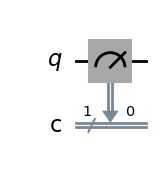

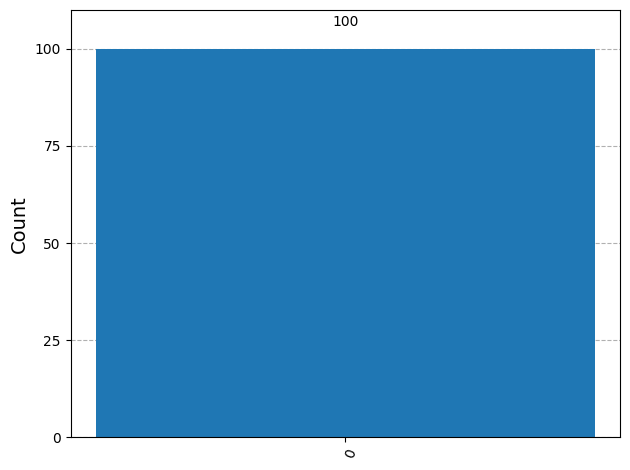

In [26]:
ejercicio_1 = QuantumCircuit(1, 1)

# TODO: agrega aquí la compuerta necesaria.
# ejercicio_1.____(0)

ejercicio_1.measure(0, 0)

ejercicio_1_preparado = transpile(ejercicio_1, simulador)
conteos_e1 = simulador.run(ejercicio_1_preparado, shots=100).result().get_counts()

print(conteos_e1)
display(ejercicio_1.draw('mpl'))
display(plot_histogram(conteos_e1))

## Ejercicio 2

Agrega una compuerta para obtener tanto ceros como unos.

{'0': 1000}


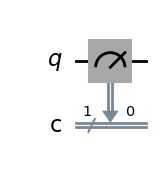

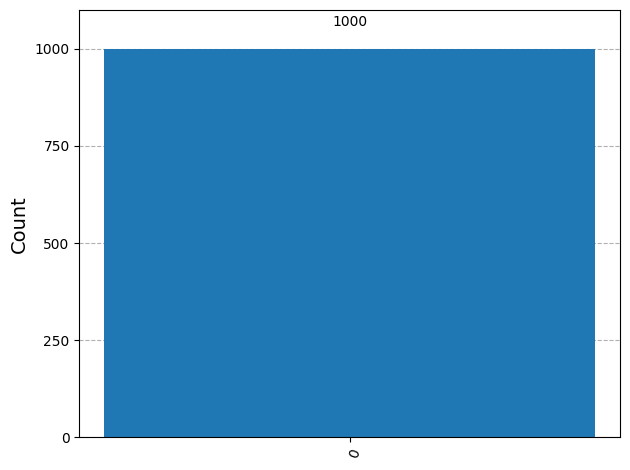

In [27]:
ejercicio_2 = QuantumCircuit(1, 1)

# TODO: agrega aquí la compuerta que crea superposición.
# ejercicio_2.____(0)

ejercicio_2.measure(0, 0)

ejercicio_2_preparado = transpile(ejercicio_2, simulador)
conteos_e2 = simulador.run(ejercicio_2_preparado, shots=1000).result().get_counts()

print(conteos_e2)
display(ejercicio_2.draw('mpl'))
display(plot_histogram(conteos_e2))

## Ejercicio 3

Cambia el valor de `shots` y observa el histograma. ¿Qué sucede cuando utilizas 10, 100 y 1,000 shots?

{'1': 5, '0': 5}


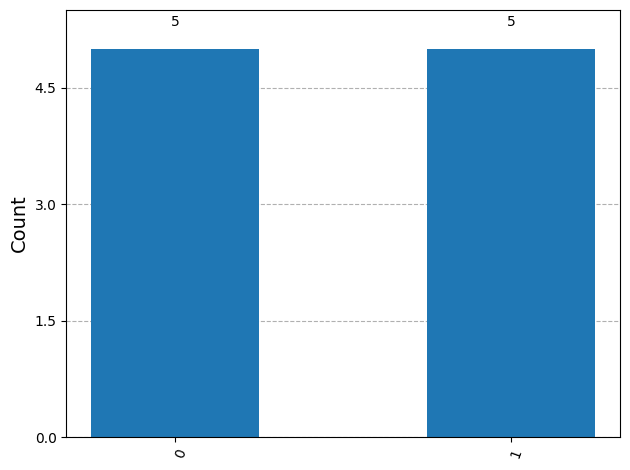

In [28]:
# Cambia este número y vuelve a ejecutar la celda.
numero_de_shots = 10

conteos_e3 = simulador.run(
    circuito_h_preparado,
    shots=numero_de_shots
).result().get_counts()

print(conteos_e3)
display(plot_histogram(conteos_e3))

---

# ✅ Cierre del módulo

En este notebook aprendimos que:

- `measure(0, 0)` mide el qubit 0 y guarda el resultado en el bit clásico 0;
- `shots` indica cuántas veces repetimos el circuito;
- `get_counts()` muestra cuántas veces apareció cada resultado;
- X produce `1` y H permite observar `0` y `1`.

## 📚 Referencias

- [IBM Quantum — Medir qubits](https://quantum.cloud.ibm.com/docs/en/guides/measure-qubits)
- [Qiskit — BasicSimulator](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.providers.basic_provider.BasicSimulator)